<a href="https://colab.research.google.com/github/krishnakanthkona-3110/My-DSA-Journey/blob/main/Trees/DSA_Trees_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
class TreeNode:
  def __init__(self,val):
    self.val = val
    self.left = None
    self.right = None

In [ ]:
root = TreeNode(13)
root.left = TreeNode(7)
root.right = TreeNode(15)
root.right.left = TreeNode(14)
root.right.right = TreeNode(19)
root.left.left = TreeNode(3)
root.left.right = TreeNode(8)

# Search in a BST

Recursion

In [ ]:
def search(root, target):
    if root is None:
        return None
    elif root.val == target:
        return root.val
    elif target < root.val:
        return search(root.left, target)
    else:
        return search(root.right, target)

In [ ]:
print(search(root, 7))

7


Time complexity: O(h), where h is the height of the BST.

Auxiliary Space: O(h) This is because of the space needed to store the recursion stack.

We can avoid the auxiliary space and recursion overhead withe help of iterative implementation. Below is the iterative implementation that works in O(h) time and O(1) auxiliary space.

Iterative

In [ ]:
def search(root,target):
  if root is None:
    return None
  temp = root
  while temp is not None:
    if temp.val == target:
      return temp.val
    elif target < temp.val:
      temp = temp.left
    else:
      temp = temp.right
  return None

In [ ]:
print(search(root, 3))

3


Time complexity: O(h), where h is the height of the BST.

Auxiliary Space: O(1)


--- BST operations take O(height). In balanced trees height is log N, but in worst case it becomes N

Time & Space Complexity

Case ------------	     Time

Balanced BST -----------	O(log N)

Skewed BST ---------	O(N)

Space: O(1) (iterative)

# Insertion in a BST

-- Insertion in Binary Search Tree using Recursion:

In [ ]:
def insert(root, key):

    # If the tree is empty, return a new node
    if root is None:
        return TreeNode(key)

    # Otherwise, recur down the tree
    if key < root.val:
        root.left = insert(root.left, key)
    else:
        root.right = insert(root.right, key)

    # Return the (unchanged) node pointer
    return root


# If the value exists → you simply don’t insert it

In [ ]:
insert(root,5)

 In the worst case, where the tree is skewed (like a linked list), the height is O(n), making the insertion time complexity O(n). In the best case, when the tree is balanced, the height is O(log n), resulting in an average insertion time complexity of O(log n).


The space complexity is primarily due to the recursion stack. In the worst case (skewed tree), the recursion depth can be O(n), leading to O(n) space complexity. In a balanced tree, the recursion depth is O(log n), so the space complexity is O(log n).

 -- Insertion in Binary Search Tree using Iterative approach:

In [ ]:
def insert_iterative(root, key):

  new_node = TreeNode(key)

  if root is None:
    return new_node

  curr = root
  while curr is not None:

    if key< curr.val:
      if curr.left is None:
        curr.left = new_node
        break
      else:
        curr = curr.left

    elif key > curr.val:
      if curr.right is None:
        curr.right = new_node
        break
      else:
        curr = curr.right

    else:     # duplicate value
      break

  return root

# Insert → Break → Return

In [ ]:
insert_iterative(root, 20)

The time complexity of the insert_iterative function is O(h), where h is the height of the binary search tree (BST). In the worst case, the height could be as large as the number of nodes n (for a skewed tree), leading to O(n). In a balanced BST, the height is approximately log n, so the average case is O(log n).


The space complexity is O(1) because the function uses a constant amount of extra space, only a few pointers (curr and new_node) regardless of the size of the tree. The insertion is performed iteratively without additional data structures that grow with input size.

# Find The Lowest Value in a BST Subtree

In [ ]:
def minvalue(root):
  current = root
  while current.left is not None:
    current = current.left
  return current.val

In [ ]:
minvalue(root)

3

# Find The Lowest Value in a BST Subtree

In [ ]:
def maxvalue(root):
  curr = root
  while curr.right is not None:
    curr = curr.right
  return curr.val

In [ ]:
maxvalue(root)

20

# Deletion in a BST

#Case -1: Deleting a Leaf Node (No children)

In [ ]:
def delete_leaf(root, key):
  if root is None:
    return None

  # If this node is the leaf to be deleted
  if root.val == key and root.left is None and root.right is None:
    return None

  # Search in left subtree
  if key < root.val:
    root.left = delete_leaf(root.left, key)

  # Search in right subtree
  elif key > root.val:
    root.right = delete_leaf(root.right, key)

  return root


In [ ]:
delete_leaf(root,3)

# Case 2: Deleting a node with ONE child

In [ ]:
def delete_one_child(root, key):
    if root is None:
        return None

    if key < root.val:
        root.left = delete_one_child(root.left, key)

    elif key > root.val:
        root.right = delete_one_child(root.right, key)

    else:
        # Node found and has exactly one child
        if root.left is None:
            return root.right
        else:
            return root.left

    return root

In [ ]:
delete_one_child(root,19)

# Case-3: Deleting a node with TWO children

-- Delete using Inorder Predecessor

In [ ]:
def deleteNode(root, key):
    # Base case: tree is empty
    if root is None:
        return None

    # Step 1: Search for the node
    if key < root.val:
        root.left = deleteNode(root.left, key)

    elif key > root.val:
        root.right = deleteNode(root.right, key)

    else:
        # Node found

        # Case 1: No child (leaf node)
        if root.left is None and root.right is None:
            return None

        # Case 2: One child
        elif root.left is None or root.right is None:
          if root.left is None:
            return root.right
          elif root.right is None:
            return root.left

        # Case 3: Two children
        # Find inorder successor (smallest in right subtree)
        successor = root.right
        while successor.left is not None:
            successor = successor.left

        # Replace root's value with successor's value
        root.val = successor.val

        # Delete the successor node
        root.right = deleteNode(root.right, successor.val)

    return root

In [ ]:
deleteNode(root, 13)

The time complexity of the deleteNode function depends primarily on the height of the binary search tree (BST). In the worst case, where the tree is skewed (like a linked list), the height is O(n), leading to a worst-case time complexity of O(n). In a balanced BST, the height is approximately O(log n), so the average-case time complexity is O(log n). The function performs a search for the node to delete, finds the node, and possibly finds the inorder successor, each of which involves traversing down the height of the tree.


The space complexity is mainly due to the recursion stack. In the worst case (skewed tree), the recursion depth can be O(n), leading to O(n) space complexity. In a balanced tree, the recursion depth is O(log n), so the average-case space complexity is O(log n)

# Delete using Inorder Predecessor

In [ ]:
def deleteNode(root, key):
    # Base case
    if root is None:
        return None

    # Step 1: Search for the node
    if key < root.val:
        root.left = deleteNode(root.left, key)

    elif key > root.val:
        root.right = deleteNode(root.right, key)

    else:
        # Node found

        # Case 1: Leaf node
        if root.left is None and root.right is None:
            return None

        # Case 2: One child
        elif root.left is None:
            return root.right
        elif root.right is None:
            return root.left

        # Case 3: Two children
        # Find inorder predecessor (largest in left subtree)
        predecessor = root.left
        while predecessor.right is not None:
            predecessor = predecessor.right

        # Replace root value with predecessor value
        root.val = predecessor.val

        # Delete the predecessor node
        root.left = deleteNode(root.left, predecessor.val)

    return root

Successor always has at most one child

So deletion becomes Case 1 or Case 2

This cleans up the duplicate node

---------------------------------------------

Inorder successor = smallest value in right subtree

Smallest value = go left until possible

-----------------------------------------------------------

Inorder predecessor = maximum value in left subtree

To find it:

Go one step left

Then keep going right until possible

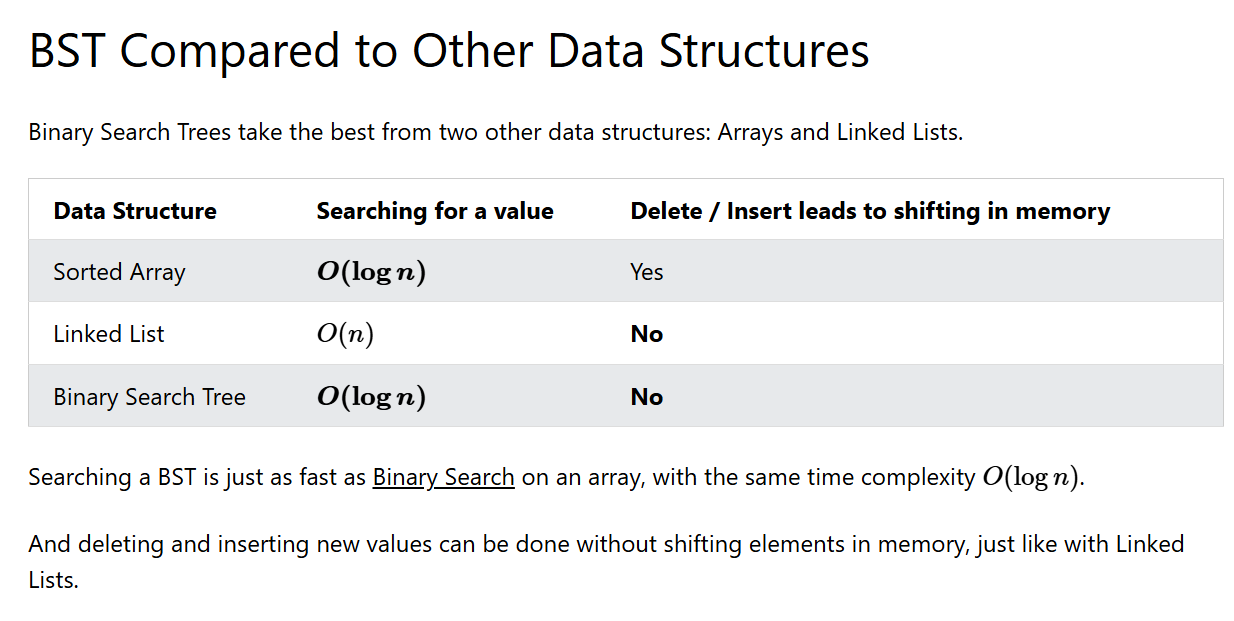

# Construct a Binary Search Tree

# Sorted Array To Balanced BST

-- Given an array where elements are sorted in ascending order, convert it to a height Balanced Binary Search Tree (BBST).

Balanced tree : a height-balanced binary tree is defined as a binary tree in which the depth of the two subtrees of every node never differ by more than 1.

Array Slicing

In [ ]:
def sortedArrayToBST(A):
    mid = (len(A) - 1) // 2
    root = TreeNode(A[mid])

    if A[:mid]:
        root.left = sortedArrayToBST(A[:mid])

    if A[mid + 1:]:
        root.right = sortedArrayToBST(A[mid + 1:])

    return root

In [ ]:
arr = [1,2,3,4,5]
root = sortedArrayToBST(arr)


Each slicing operation creates a new array.

That means:

At every recursive call → new array copy

Extra memory usage

Extra time copying elements

The total slicing cost across all recursive calls sums up to O(N log N) in the worst case.


 Space   ---   O(n log n)

In [ ]:
def sortedArrayToBST( A, l=0, r=None):
    if r is None:
        r = len(A) - 1

    if l > r:
        return None

    mid = (l + r) // 2
    root = TreeNode(A[mid])

    root.left = sortedArrayToBST(A, l, mid - 1)
    root.right =sortedArrayToBST(A, mid + 1, r)

    return root

In [ ]:
arr = [1,2,3,4,5]
sortedArrayToBST(arr)

Optimized solution

In [ ]:
def sortedArrayToBST(self, A):
    def build(l, r):
        if l > r:
            return None

        mid = (l + r) // 2
        root = TreeNode(A[mid])
        root.left = build(l, mid - 1)
        root.right = build(mid + 1, r)
        return root

    return build(0, len(A) - 1)

Time Complexity is O(n) because each element is used once.

Space Complexity is O(log n) due to recursion stack.
The tree itself takes O(n) space.

# Question - Valid Binary Search Tree

You are given a binary tree represented by root A. You need to check if it is a Binary Search Tree or not.


Assume a BST is defined as follows:

1) The left subtree of a node contains only nodes with keys less than the node's key.

2) The right subtree of a node contains only nodes with keys greater than the node's key.

3) Both the left and right subtrees must also be binary search trees.



For every node:

1. Finds maximum in left subtree

2. Finds minimum in right subtree

3. Checks BST condition

4. Recursively verifies left and right subtrees

For every node, we compute max of left subtree and min of right subtree.
Each computation may traverse O(n) nodes.
Since we do this for n nodes, total time becomes O(n²).
Space complexity is O(n) due to recursion stack in worst case

In [ ]:
# Brute Force code,


def isBST(root):

    # Helper to get maximum value in a subtree
    def getMax(node):
        if node is None:
            return float('-inf')
        return max(node.val, getMax(node.left), getMax(node.right))

    # Helper to get minimum value in a subtree
    def getMin(node):
        if node is None:
            return float('inf')
        return min(node.val, getMin(node.left), getMin(node.right))

    # Base case
    if root is None:
        return True

    # Get max from left subtree
    mx = getMax(root.left)

    # Get min from right subtree
    mn = getMin(root.right)

    # Check BST condition
    if root.val <= mx or root.val >= mn:
        return False

    # Recursively check left and right subtrees
    if not isBST(root.left):
        return False

    if not isBST(root.right):
        return False

    return True

# Optimal Solution

In [ ]:
def isValidBST(root):

    def validate(node, low, high):
        if node is None:
            return True

        # Node value must lie strictly between low and high
        if node.val <= low or node.val >= high:
            return False

        # Left subtree must be < node.val
        # Right subtree must be > node.val
        return (validate(node.left, low, node.val) and
                validate(node.right, node.val, high))

    return validate(root, float('-inf'), float('inf'))

For every node:

Left subtree values must be less than current node

Right subtree values must be greater than current node

AND must also respect all ancestor constraints

We enforce this using (low, high) limits.

✅ Time Complexity → O(n)

Each node is visited exactly once.

✅ Space Complexity → O(h)

Where h = height of tree

Balanced tree → O(log n)

Skewed tree → O(n)

In [ ]:
# ccbbdf8